In [10]:
# ============================================
# CHANGE THESE TWO LINES
# ============================================
GITHUB_USER = 'skm48'
REPO_NAME   = 'MINI_PROJECT'

import os

if not os.path.exists(f'/{REPO_NAME}'):
    # First time — clone
    !git clone https://github.com/Skm48/MINI_PROJECT.git
    print('Repo cloned!')
else:
    # Already cloned — pull latest
    !cd /content/{REPO_NAME} && git pull
    print('Pulled latest changes!')

os.chdir(f'/content/{REPO_NAME}')
print(f'Working directory: {os.getcwd()}')

Cloning into 'MINI_PROJECT'...
remote: Enumerating objects: 479, done.
remote: Counting objects: 100% (148/148), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 479 (delta 135), reused 125 (delta 119), pack-reused 331 (from 2)
Receiving objects: 100% (479/479), 778.76 MiB | 21.46 MiB/s, done.
Resolving deltas: 100% (220/220), done.
Updating files: 100% (67/67), done.
Repo cloned!
Working directory: /content/MINI_PROJECT


In [12]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
!cp /content/drive/MyDrive/Dataset.zip /content/MINI_PROJECT/data/
!unzip -q /content/MINI_PROJECT/data/Dataset.zip -d /content/MINI_PROJECT/data/

In [14]:
# Remove the Mac junk folder and nested duplicate
!rm -rf /content/MINI_PROJECT/data/chest_xray/__MACOSX
!rm -rf /content/MINI_PROJECT/data/chest_xray/chest_xray

# Check it's clean
!ls /content/MINI_PROJECT/data/chest_xray

test  train  val


In [15]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
from pathlib import Path

import torch
from torchvision import transforms

from src.utils import set_seed, get_device, load_config
from src.dataset import (
    collect_image_paths,
    stratified_split,
    get_transforms,
    get_dataloaders,
    compute_class_weights,
)

set_seed(42)
device = get_device()
config = load_config()

print('All imports ready')

Using GPU: Tesla T4
All imports ready


In [16]:
# Build everything in one call
loaders = get_dataloaders(config)

Total images found: 5856
  By original split: {'train': np.int64(5216), 'test': np.int64(624), 'val': np.int64(16)}
  By label: {1: np.int64(4273), 0: np.int64(1583)}

Merged train+val: 5232 images
Original test kept: 624 images

New split sizes:
  Train: 4650  (Normal: 1199, Pneumonia: 3451)
  Val:   582  (Normal: 150, Pneumonia: 432)
  Test:  624  (Normal: 234, Pneumonia: 390)

Split indices saved to: data/split_indices.csv

Class weights: Normal=1.939, Pneumonia=0.674

DataLoaders ready:
  Train: 146 batches (4650 images)
  Val:   19 batches (582 images)
  Test:  20 batches (624 images)


In [17]:
import torch
import torch.nn as nn
import torchvision.models as models

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# VGG16
vgg16 = models.vgg16(weights='IMAGENET1K_V1')
vgg16.classifier = nn.Sequential(
    nn.Linear(512 * 7 * 7, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 2),
)
vgg16.load_state_dict(torch.load('model/checkpoints/vgg16_phase1_best.pth', map_location=device))
vgg16 = vgg16.to(device)
vgg16.eval()

# ResNet50
resnet50 = models.resnet50(weights='IMAGENET1K_V2')
resnet50.fc = nn.Sequential(
    nn.Dropout(0.4),        # index 0 — no weights, invisible in checkpoint
    nn.Linear(2048, 2),     # index 1 — fc.1.weight, fc.1.bias ✅
)
resnet50.load_state_dict(torch.load('model/checkpoints/resnet50_best.pth', map_location=device))
resnet50 = resnet50.to(device)
resnet50.eval()

# EfficientNet-B0
efficientnet = models.efficientnet_b0(weights='IMAGENET1K_V1')
efficientnet.classifier = nn.Sequential(
    nn.Linear(1280, 256),   # index 0
    nn.ReLU(),               # index 1
    nn.Dropout(0.5),         # index 2
    nn.Linear(256, 2),       # index 3
)
efficientnet.load_state_dict(torch.load('model/checkpoints/efficientnet_b0_best.pth', map_location=device))
efficientnet = efficientnet.to(device)
efficientnet.eval()

print("All 3 models loaded")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 86.9MB/s]


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 160MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 117MB/s] 


All 3 models loaded


In [19]:
import numpy as np
from tqdm import tqdm

def extract_features(model, model_name, loader, device):
    """Extract features from the layer before the classifier."""
    features = []
    labels_list = []

    # Hook to capture features
    feature_output = {}

    if model_name == 'vgg16':
        # Features come from avgpool (after conv blocks, before classifier)
        hook = model.avgpool.register_forward_hook(
            lambda m, inp, out: feature_output.update({'feat': out})
        )
    elif model_name == 'resnet50':
        hook = model.avgpool.register_forward_hook(
            lambda m, inp, out: feature_output.update({'feat': out})
        )
    elif model_name == 'efficientnet':
        hook = model.avgpool.register_forward_hook(
            lambda m, inp, out: feature_output.update({'feat': out})
        )

    model.eval()
    with torch.no_grad():
        for images, labels in tqdm(loader, desc=f"Extracting {model_name}"):
            images = images.to(device)
            _ = model(images)  # forward pass triggers the hook

            feat = feature_output['feat'].squeeze()  # remove spatial dims
            if feat.dim() == 1:
                feat = feat.unsqueeze(0)
            features.append(feat.cpu().numpy())
            labels_list.extend(labels.numpy())

    hook.remove()
    features = np.concatenate(features, axis=0)
    labels_arr = np.array(labels_list)
    print(f"{model_name} features shape: {features.shape}")
    return features, labels_arr

In [20]:
# Train features
vgg_train_feat, train_labels = extract_features(vgg16, 'vgg16', loaders['train'], device)
res_train_feat, _ = extract_features(resnet50, 'resnet50', loaders['train'], device)
eff_train_feat, _ = extract_features(efficientnet, 'efficientnet', loaders['train'], device)

# Val features
vgg_val_feat, val_labels = extract_features(vgg16, 'vgg16', loaders['val'], device)
res_val_feat, _ = extract_features(resnet50, 'resnet50', loaders['val'], device)
eff_val_feat, _ = extract_features(efficientnet, 'efficientnet', loaders['val'], device)

# Test features
vgg_test_feat, test_labels = extract_features(vgg16, 'vgg16', loaders['test'], device)
res_test_feat, _ = extract_features(resnet50, 'resnet50', loaders['test'], device)
eff_test_feat, _ = extract_features(efficientnet, 'efficientnet', loaders['test'], device)

# Flatten VGG16 features from (4650, 512, 7, 7) to (4650, 25088)
vgg_train_feat = vgg_train_feat.reshape(vgg_train_feat.shape[0], -1)
vgg_val_feat = vgg_val_feat.reshape(vgg_val_feat.shape[0], -1)
vgg_test_feat = vgg_test_feat.reshape(vgg_test_feat.shape[0], -1)

print(f"VGG16 flattened: {vgg_train_feat.shape}")

# Now concatenate
train_fused = np.concatenate([vgg_train_feat, res_train_feat, eff_train_feat], axis=1)
val_fused = np.concatenate([vgg_val_feat, res_val_feat, eff_val_feat], axis=1)
test_fused = np.concatenate([vgg_test_feat, res_test_feat, eff_test_feat], axis=1)

print(f"\nFused feature sizes:")
print(f"  Train: {train_fused.shape}")
print(f"  Val:   {val_fused.shape}")
print(f"  Test:  {test_fused.shape}")

print(f"\nFused feature sizes:")
print(f"  Train: {train_fused.shape}")
print(f"  Val:   {val_fused.shape}")
print(f"  Test:  {test_fused.shape}")

Extracting vgg16: 100%|██████████| 146/146 [01:23<00:00,  1.74it/s]


vgg16 features shape: (4650, 512, 7, 7)


Extracting resnet50: 100%|██████████| 146/146 [01:26<00:00,  1.69it/s]


resnet50 features shape: (4650, 2048)


Extracting efficientnet: 100%|██████████| 146/146 [01:18<00:00,  1.87it/s]


...

vgg16 features shape: (624, 512, 7, 7)


Extracting resnet50: 100%|██████████| 20/20 [00:10<00:00,  1.98it/s]


resnet50 features shape: (624, 2048)


Extracting efficientnet: 100%|██████████| 20/20 [00:09<00:00,  2.07it/s]


efficientnet features shape: (624, 1280)
VGG16 flattened: (4650, 25088)

Fused feature sizes:
  Train: (4650, 28416)
  Val:   (582, 28416)
  Test:  (624, 28416)

Fused feature sizes:
  Train: (4650, 28416)
  Val:   (582, 28416)
  Test:  (624, 28416)


In [24]:
from sklearn.preprocessing import StandardScaler

# --- Pool VGG only if it isn't already pooled ---
def pool_vgg(x):
    # already pooled to (N, 512)? leave it alone
    if x.ndim == 2 and x.shape[1] == 512:
        return x
    # otherwise it's (N, 512, 7, 7) or flattened (N, 25088) — pool it
    return x.reshape(-1, 512, 7, 7).mean(axis=(2, 3))

vgg_train_feat = pool_vgg(vgg_train_feat)
vgg_val_feat   = pool_vgg(vgg_val_feat)
vgg_test_feat  = pool_vgg(vgg_test_feat)

print(f"VGG16 pooled: {vgg_train_feat.shape}")  # (N, 512)

# --- Scale each model's features separately ---
sc_vgg, sc_res, sc_eff = StandardScaler(), StandardScaler(), StandardScaler()

vgg_train_feat = sc_vgg.fit_transform(vgg_train_feat)
res_train_feat = sc_res.fit_transform(res_train_feat)
eff_train_feat = sc_eff.fit_transform(eff_train_feat)

vgg_val_feat = sc_vgg.transform(vgg_val_feat)
res_val_feat = sc_res.transform(res_val_feat)
eff_val_feat = sc_eff.transform(eff_val_feat)

vgg_test_feat = sc_vgg.transform(vgg_test_feat)
res_test_feat = sc_res.transform(res_test_feat)
eff_test_feat = sc_eff.transform(eff_test_feat)

# --- Concatenate ---
train_fused = np.concatenate([vgg_train_feat, res_train_feat, eff_train_feat], axis=1)
val_fused   = np.concatenate([vgg_val_feat, res_val_feat, eff_val_feat], axis=1)
test_fused  = np.concatenate([vgg_test_feat, res_test_feat, eff_test_feat], axis=1)

print(f"New fused size: {train_fused.shape}")  # (N, 3840)

VGG16 pooled: (4650, 512)
New fused size: (4650, 3840)


In [37]:
from torch.utils.data import TensorDataset, DataLoader
import random

# --- Seed everything for reproducible fusion training ---
def set_fusion_seed(s=42):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)

set_fusion_seed(42)

# Convert to tensors
train_dataset = TensorDataset(torch.FloatTensor(train_fused), torch.LongTensor(train_labels))
val_dataset   = TensorDataset(torch.FloatTensor(val_fused),   torch.LongTensor(val_labels))
test_dataset  = TensorDataset(torch.FloatTensor(test_fused),  torch.LongTensor(test_labels))

# Seeded generator so the shuffle order is fixed too
g = torch.Generator(); g.manual_seed(42)
fusion_train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, generator=g)
fusion_val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
fusion_test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

# Fusion classifier
input_size = train_fused.shape[1]  # 3840 after pooling + scaling

fusion_model = nn.Sequential(
    nn.Linear(input_size, 256),
    nn.BatchNorm1d(256),     # stabilises training, acts as a regulariser
    nn.ReLU(),
    nn.Dropout(0.6),         # heavier dropout — lots of features, few samples

    nn.Linear(256, 64),
    nn.BatchNorm1d(64),
    nn.ReLU(),
    nn.Dropout(0.4),

    nn.Linear(64, 2),
).to(device)

print(f"Fusion input size: {input_size}")
print(f"Fusion model:\n{fusion_model}")

Fusion input size: 3840
Fusion model:
Sequential(
  (0): Linear(in_features=3840, out_features=256, bias=True)
  (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.6, inplace=False)
  (4): Linear(in_features=256, out_features=64, bias=True)
  (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU()
  (7): Dropout(p=0.4, inplace=False)
  (8): Linear(in_features=64, out_features=2, bias=True)
)


In [38]:
criterion = nn.CrossEntropyLoss(weight=loaders['class_weights'].to(device))
optimizer = torch.optim.Adam(fusion_model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

num_epochs = 30
best_val_loss = float('inf')

for epoch in range(num_epochs):
    # Train
    fusion_model.train()
    running_loss, correct, total = 0.0, 0, 0

    for features, labels in fusion_train_loader:
        features, labels = features.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = fusion_model(features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * features.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    # Validate
    fusion_model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for features, labels in fusion_val_loader:
            features, labels = features.to(device), labels.to(device)
            outputs = fusion_model(features)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * features.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

    val_loss = running_loss / total
    val_acc = correct / total
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(fusion_model.state_dict(), 'model/checkpoints/fusion_best.pth')

    print(f"Epoch {epoch+1}: train_loss={train_loss:.4f} train_acc={train_acc:.4f} | val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

print(f"\nBest val loss: {best_val_loss:.4f}")

Epoch 1: train_loss=0.3635 train_acc=0.8282 | val_loss=0.2656 val_acc=0.8454
Epoch 2: train_loss=0.2145 train_acc=0.9168 | val_loss=0.2270 val_acc=0.8694
Epoch 3: train_loss=0.1629 train_acc=0.9346 | val_loss=0.1546 val_acc=0.9175
Epoch 4: train_loss=0.1398 train_acc=0.9460 | val_loss=0.1682 val_acc=0.9175
Epoch 5: train_loss=0.1130 train_acc=0.9589 | val_loss=0.3090 val_acc=0.8540
Epoch 6: train_loss=0.1106 train_acc=0.9578 | val_loss=0.2025 val_acc=0.8814
Epoch 7: train_loss=0.1064 train_acc=0.9598 | val_loss=0.1659 val_acc=0.9381
Epoch 8: train_loss=0.0829 train_acc=0.9662 | val_loss=0.2968 val_acc=0.8660
Epoch 9: train_loss=0.0623 train_acc=0.9770 | val_loss=0.1981 val_acc=0.9003
Epoch 10: train_loss=0.0501 train_acc=0.9849 | val_loss=0.2032 val_acc=0.8969
Epoch 11: train_loss=0.0575 train_acc=0.9791 | val_loss=0.2289 val_acc=0.8969
Epoch 12: train_loss=0.0363 train_acc=0.9886 | val_loss=0.2123 val_acc=0.9003
Epoch 13: train_loss=0.0446 train_acc=0.9854 | val_loss=0.2036 val_acc=0.

              precision    recall  f1-score   support

      Normal       0.90      0.79      0.84       234
   Pneumonia       0.88      0.95      0.91       390

    accuracy                           0.89       624
   macro avg       0.89      0.87      0.88       624
weighted avg       0.89      0.89      0.89       624

Accuracy:  0.8878
F1 Score:  0.8862
AUC-ROC:   0.9452


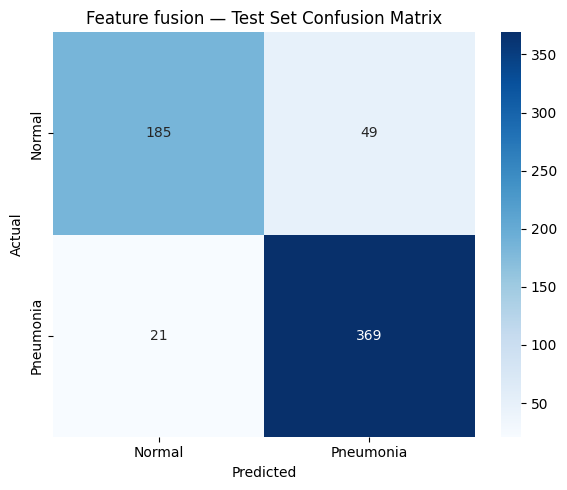


True Negatives (Normal correctly):   185
False Positives (Normal → Pneumonia): 49
False Negatives (Pneumonia → Normal): 21
True Positives (Pneumonia correctly): 369


In [39]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fusion_model.load_state_dict(torch.load('model/checkpoints/fusion_best.pth', map_location=device))
fusion_model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for features, labels in fusion_test_loader:
        features = features.to(device)
        outputs = fusion_model(features)
        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=['Normal', 'Pneumonia']))

accuracy = sum(1 for a, b in zip(all_labels, all_preds) if a == b) / len(all_labels)
f1 = f1_score(all_labels, all_preds, average='weighted')
auc = roc_auc_score(all_labels, all_probs)
print(f"Accuracy:  {accuracy:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC-ROC:   {auc:.4f}")

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Feature fusion — Test Set Confusion Matrix')
plt.tight_layout()
plt.savefig('outputs/figures/fusion_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Print what the confusion matrix means
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives (Normal correctly):   {tn}")
print(f"False Positives (Normal → Pneumonia): {fp}")
print(f"False Negatives (Pneumonia → Normal): {fn}")
print(f"True Positives (Pneumonia correctly): {tp}")

In [2]:
!cd /content/MINI_PROJECT && git config user.name "Skm48"
!cd /content/MINI_PROJECT && git config user.email "skm48@student.le.ac.uk"

/bin/bash: line 1: cd: /content/MINI_PROJECT: No such file or directory
/bin/bash: line 1: cd: /content/MINI_PROJECT: No such file or directory


In [3]:
!cd /content/MINI_PROJECT && git remote set-url origin https://Skm48@github.com/Skm48/MINI_PROJECT.git


/bin/bash: line 1: cd: /content/MINI_PROJECT: No such file or directory


In [9]:
!cp /content/drive/MyDrive/Colab\ Notebooks/05a_Model_Fusion_Feature.ipynb /content/MINI_PROJECT/notebooks/

cp: target '/content/MINI_PROJECT/notebooks/' is not a directory
